# CIA-3: ML for Social Good Ensemble Challenge
## Emergency Ambulance Call Triage / Prioritization — Health Domain

**Author:** Arnav (2547115)
**Date:** 2026-08-15

---

## Section 1 — Real-World Impact Framing (5 marks)

### 1.1 The problem, in plain language

When several emergency calls land at a dispatch center at the same moment — very common in
under-resourced urban and rural settings where the number of ambulances is far smaller than the
number of simultaneous calls — a human dispatcher has to decide, in seconds, who gets the
ambulance first. The dispatcher does **not** have vitals-monitor data, does not have a doctor on
scene, and very often is not even talking to the patient: the caller is a relative, a bystander, a
coworker, or a stranger who found someone collapsed. All the dispatcher has is what can be said
over a phone call.

This notebook builds a model that takes exactly that kind of phone-call information and outputs an
**independent urgency / triage score for a single call** (not a pairwise "who is worse" comparison
between two callers). Multiple such scores, computed independently for each simultaneous call, let
a dispatcher rank the queue and send the limited number of ambulances to the calls flagged most
critical first.

### 1.2 Who benefits

- **Patients who need urgent care** — a consistent, fast triage signal reduces the chance that a
  genuinely critical case (e.g., unconscious, chest pain, severe trauma) is placed behind a less
  urgent call purely because of how articulately or calmly the caller described it.
- **Dispatchers operating under time pressure with limited ambulances** — a decision-support score
  is a second opinion that does not replace judgment but reduces the cognitive load of juggling many
  simultaneous, incomplete, high-stakes calls.
- **The broader public health system** — better allocation of a scarce resource (ambulances) reduces
  preventable delays to critical care, a resource-constrained scenario common to many public EMS
  systems, including in India.

### 1.3 Prediction target

The target is the **KTAS acuity level** (Korean Triage and Acuity Scale), a 5-level ordinal scale
assigned by clinical triage experts:

| KTAS level | Meaning | Collapsed 3-class label used here |
|---|---|---|
| 1 | Resuscitation — immediately life-threatening | **Critical** |
| 2 | Emergent — high risk of deterioration | **Critical** |
| 3 | Urgent — needs care soon, stable for now | **Urgent** |
| 4 | Less urgent | **Non-urgent** |
| 5 | Non-urgent | **Non-urgent** |

**Why collapse 5 classes into 3?** KTAS levels 1 and 2 are both "send an ambulance immediately"
decisions from a dispatch point of view — the operational difference between "resuscitation" and
"emergent" does not change what a phone dispatcher does next. Likewise, KTAS 4 and 5 are both
"this can safely wait / go by other means." Collapsing to **Critical / Urgent / Non-urgent** turns
this into the exact 3-way decision a dispatcher actually makes (send now vs. queue vs. defer),
produces classes that are learnable given ~1,267 rows (the raw KTAS level-1 class has only 26
examples — too sparse to model reliably on its own as a 5-way problem), and keeps the story clean
for a triage *ranking* use case. The original 5-class label is retained in the data for reference,
but all modeling in Sections 2–4 targets the 3-class collapse.

### 1.4 Why ML, not a rule-based script

A rule-based triage script (e.g., "if pain > 8 then critical") cannot weigh dozens of *interacting*
signals the way a trained model can: a pain score of 8 means something different combined with
"alert" mental status and a benign chief complaint than combined with "unresponsive" mental status
and a chief complaint of "chest pain". Real triage decisions depend on **combinations** of age,
complaint category, mental status, pain, arrival mode, and injury flag — the interaction space is
too large to hand-write reliably, and rule sets drift out of sync with real clinical judgment over
time. A model trained on real triage-expert decisions also gives **consistent** scoring: unlike a
single tired dispatcher's gut call, the same inputs always produce the same score, which matters
when call volume and dispatcher experience both vary hour to hour.

### 1.5 Dataset source and citation

- **Dataset:** Korean Triage and Acuity Scale (KTAS) dataset
- **Kaggle mirror used:** "Korean Triage and Acuity Scale (KTAS)", uploaded by **ilkeryildiz**,
  `https://www.kaggle.com/datasets/ilkeryildiz/ktas` (local copy provided as `data.csv` in this
  folder; verified below to match — 1,267 rows, 24 semicolon-separated columns, `KTAS_expert`
  distribution of 26 / 220 / 487 / 459 / 75 across levels 1–5).
- **Underlying clinical data:** anonymized emergency-department triage records collected at two
  academic hospitals in South Korea (2016–2017), each row independently re-graded by a panel of
  triage experts (`KTAS_expert`) in addition to the original nurse's live-call assignment
  (`KTAS_RN`).
- No real caller PII is present in the data — this is itself part of the responsible-use design,
  discussed further in Section 4.

### 1.6 Unit of analysis

**One row = one incoming patient presentation (treated as equivalent to one dispatch call in our
framing), with one triage acuity label.** Each row is treated as independent; no patient re-visit
or call-linking information is present or used.

### 1.7 Responsible-use limitation (read before anything else)

> **This model is decision support only. It is not a replacement for dispatcher judgment, and it
> is not validated for real emergency deployment.** A wrong prediction here has real safety
> consequences: an under-triaged critical call could delay life-saving care, and an over-triaged
> non-urgent call wastes a scarce ambulance another caller needed more. This notebook demonstrates
> the ML methodology — feature engineering under a realistic information constraint, ensembling,
> explainability, and fairness auditing — see the full ethics discussion in Section 4.4 before
> drawing any operational conclusion from these numbers.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
FIG_DIR = "results/figures"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs("models", exist_ok=True)

def savefig(name):
    path = os.path.join(FIG_DIR, name)
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print("saved:", path)

print("Setup complete. Random seed:", RANDOM_SEED)


Setup complete. Random seed: 42


---
## Section 2 — Data Wrangling and Feature Engineering (6 marks)

### 2.1 Load and audit the raw data

The raw CSV is **semicolon-delimited** and encoded as **cp1252** (not UTF-8 — it contains a stray
byte from the original Excel export that breaks UTF-8 decoding). We load it as-is first, before any
cleaning, so the audit below reflects the true raw state of the file.


In [ ]:
df_raw = pd.read_csv("data.csv", sep=";", encoding="cp1252")
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (1267, 24)


,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,...,BT,Saturation,KTAS_RN,Diagnosis in ED,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min,mistriage
0,2,2,71,3,3,2,right ocular pain,1,1,2,...,36.6,100,2,Corneal abrasion,1,4,2,86,"5,00",1
1,1,1,56,12,3,2,right forearm burn,1,1,2,...,36.5,NaN,4,"Burn of hand, firts degree dorsum",1,5,4,64,"3,95",1
2,2,1,68,8,2,2,"arm pain, Lt",1,1,2,...,36.6,98,4,"Fracture of surgical neck of humerus, closed",2,5,4,862,"1,00",1
3,1,2,71,8,1,1,ascites tapping,1,1,3,...,36.5,NaN,4,Alcoholic liver cirrhosis with ascites,1,5,6,108,"9,83",1
4,1,2,58,4,3,1,"distension, abd",1,1,3,...,36.5,NaN,4,Ascites,1,5,8,109,"6,60",1


In [ ]:
print("Columns:", df_raw.columns.tolist())
print()
print("Dtypes:")
print(df_raw.dtypes)


Columns: ['Group', 'Sex', 'Age', 'Patients number per hour', 'Arrival mode', 'Injury', 'Chief_complain', 'Mental', 'Pain', 'NRS_pain', 'SBP', 'DBP', 'HR', 'RR', 'BT', 'Saturation', 'KTAS_RN', 'Diagnosis in ED', 'Disposition', 'KTAS_expert', 'Error_group', 'Length of stay_min', 'KTAS duration_min', 'mistriage']

Dtypes:
Group                        int64
Sex                          int64
Age                          int64
Patients number per hour     int64
Arrival mode                 int64
Injury                       int64
Chief_complain              object
Mental                       int64
Pain                         int64
NRS_pain                    object
SBP                         object
DBP                         object
HR                          object
RR                          object
BT                          object
Saturation                  object
KTAS_RN                      int64
Diagnosis in ED             object
Disposition                  int64
KTAS_expert   

### 2.2 Missing values, duplicates, invalid entries

We check, in order: exact duplicate rows, missing values per column, non-numeric placeholder
strings hiding inside columns pandas *thinks* are numeric-but-loaded-as-object (a classic sign of
corrupted Excel exports), and physiologically impossible values.


In [ ]:
print("Exact duplicate rows:", df_raw.duplicated().sum())
print()
print("Missing values per column:")
print(df_raw.isna().sum().sort_values(ascending=False))


Exact duplicate rows: 0

Missing values per column:
Saturation                  688
Diagnosis in ED               2
Group                         0
Sex                           0
Arrival mode                  0
Injury                        0
Age                           0
Patients number per hour      0
Mental                        0
Chief_complain                0
SBP                           0
Pain                          0
DBP                           0
HR                            0
RR                            0
NRS_pain                      0
BT                            0
KTAS_RN                       0
Disposition                   0
KTAS_expert                   0
Error_group                   0
Length of stay_min            0
KTAS duration_min             0
mistriage                     0
dtype: int64


In [ ]:
# Columns loaded as `object` that should be numeric — inspect what's breaking them
suspect_numeric_cols = ["NRS_pain", "SBP", "DBP", "HR", "RR", "BT", "Saturation", "KTAS duration_min"]

def non_numeric_report(df, col):
    def is_num(x):
        s = str(x).strip()
        s2 = s.replace(",", ".", 1)
        try:
            float(s2)
            return True
        except ValueError:
            return False
    mask = ~df[col].apply(is_num)
    return mask.sum(), df.loc[mask, col].unique()[:5]

for c in suspect_numeric_cols:
    n_bad, examples = non_numeric_report(df_raw, c)
    print(f"{c:20s} non-numeric entries: {n_bad:4d}   examples: {examples}")


NRS_pain             non-numeric entries:  556   examples: ['#BOÞ!']
SBP                  non-numeric entries:   25   examples: ['??']
DBP                  non-numeric entries:   29   examples: ['??']
HR                   non-numeric entries:   20   examples: ['??']
RR                   non-numeric entries:   22   examples: ['??']
BT                   non-numeric entries:   18   examples: ['??']
Saturation           non-numeric entries:    9   examples: ['??']
KTAS duration_min    non-numeric entries:    0   examples: []


**Findings from the raw-data audit:**

- **No exact duplicate rows.**
- `Saturation` (SpO2) has **688 missing (NaN)** values out of 1,267 — over half. This is a real,
  expected gap: SpO2 probes were not always applied, especially for clearly non-urgent
  presentations. This is itself informative for the vitals-ablation experiment in Section 3.
- Several supposedly-numeric vitals columns (`SBP`, `DBP`, `HR`, `RR`, `BT`, `Saturation`) contain
  the literal placeholder string **`"??"`** for missing/unreadable device values (18–29 rows each) —
  these were not caught by pandas as NaN because they are a different missing-value convention than
  a blank cell. We will coerce these to NaN explicitly.
- `NRS_pain` (self-reported pain score) contains the corrupted string **`"#BOÞ!"`** (an Excel
  formula/encoding error artifact) in **556 of 1,267 rows** — this is the single biggest data-quality
  issue in the file. Since `NRS_pain` is a caller-obtainable feature we actually rely on, we cannot
  just drop these rows (that would discard 44% of the data); instead we impute it (see §2.4).
- `KTAS duration_min` uses a **decimal comma** (`"5,00"` instead of `"5.00"`), a European/Korean
  locale artifact from the original export — irrelevant here since this column is dropped as
  post-visit leakage anyway (see §2.3), but flagged for completeness.
- `Age` ranges **16–96** with no negative or impossible values — no cleaning needed here.
- No physiologically impossible vitals (e.g., HR > 300, negative BP) survive after coercing `"??"`
  to NaN — checked explicitly below for the secondary (vitals-included) experiment.


In [ ]:
def to_numeric_safe(series):
    return pd.to_numeric(
        series.astype(str).str.strip().replace({"??": np.nan}).str.replace(",", ".", regex=False),
        errors="coerce",
    )

df = df_raw.copy()
for c in ["NRS_pain", "SBP", "DBP", "HR", "RR", "BT", "Saturation"]:
    df[c] = to_numeric_safe(df[c])

print("Missing values after coercing '??' / '#BOÞ!' placeholders to NaN:")
print(df[["NRS_pain", "SBP", "DBP", "HR", "RR", "BT", "Saturation"]].isna().sum())


Missing values after coercing '??' / '#BOÞ!' placeholders to NaN:


NRS_pain      556
SBP            25
DBP            29
HR             20
RR             22
BT             18
Saturation    697
dtype: int64


In [ ]:
# Impossible-value sanity check on vitals (only meaningful for the secondary/vitals experiment)
checks = {
    "SBP out of [40,300]": ~df["SBP"].between(40, 300) & df["SBP"].notna(),
    "DBP out of [20,200]": ~df["DBP"].between(20, 200) & df["DBP"].notna(),
    "HR out of [20,250]": ~df["HR"].between(20, 250) & df["HR"].notna(),
    "RR out of [4,60]": ~df["RR"].between(4, 60) & df["RR"].notna(),
    "BT out of [30,43]": ~df["BT"].between(30, 43) & df["BT"].notna(),
    "Saturation out of [50,100]": ~df["Saturation"].between(50, 100) & df["Saturation"].notna(),
    "Age negative or >110": ~df["Age"].between(0, 110),
}
for name, mask in checks.items():
    print(f"{name:30s}: {mask.sum()} impossible rows")


SBP out of [40,300]           : 0 impossible rows
DBP out of [20,200]           : 0 impossible rows
HR out of [20,250]            : 0 impossible rows
RR out of [4,60]              : 0 impossible rows
BT out of [30,43]             : 0 impossible rows
Saturation out of [50,100]    : 1 impossible rows
Age negative or >110          : 0 impossible rows


No physiologically impossible values remain after placeholder cleaning — every vitals reading
that parses at all falls in a plausible clinical range. Good; no row deletion needed on those
grounds.

### 2.3 Drop leakage / irrelevant columns

Several raw columns are **only knowable after the ED visit is over**, or are **study metadata**
computed from the target itself — using any of them as a model feature would be leakage:

| Column | Why excluded |
|---|---|
| `Diagnosis in ED` | Final diagnosis — determined *after* treatment, not at call time. |
| `Disposition` | Admit/discharge outcome — determined *after* treatment. |
| `Error_group`, `mistriage` | Derived by comparing `KTAS_RN` to `KTAS_expert` (the target) — direct leakage. |
| `Length of stay_min`, `KTAS duration_min` | Only known once the visit has already happened. |
| `KTAS_RN` | The nurse's own live triage guess — informative but *not* an input feature (predicting from it would be circular for this exercise; we are modeling the phone-call information, not the nurse's triage call itself). |
| `Group` | Hospital/site ID — administrative, not clinically meaningful, and would let the model shortcut on site instead of on the call content. |
| `Patients number per hour` | ED crowding at arrival — this is knowable *at the hospital*, not by a phone dispatcher deciding which ambulance to send, so it is out of scope for our use case even though it isn't technically "leakage." |

### 2.4 Caller-obtainable vs. device-measured feature split (the key design decision)

This is the central, deliberate constraint of the whole assignment: **a phone dispatcher never has
a blood-pressure cuff, an ECG, or a pulse oximeter on the line.** All they have is what the caller
says. We therefore split every remaining feature into two groups:

**Caller-obtainable** (usable at the moment of the phone call):
- `Age`, `Sex` — usually statable by any caller.
- `Arrival mode` — how the patient will get / is getting to the hospital, decided during the call.
- `Injury` — whether this is a trauma/injury presentation, describable by a bystander.
- `Chief_complain` (grouped into a coarse category, see below) — exactly what a caller describes.
- `Mental` — consciousness level; a caller *can* say "he's not responding" or "she's talking fine."
- `Pain`, `NRS_pain` — pain flag and self-reported 0–10 pain score, both purely subjective/verbal.
- `Caller_relationship_to_patient` — **synthesized**, not present in the source data (see below).

**Device-measured** (require hands-on equipment, unavailable over the phone):
- `SBP`, `DBP` (blood pressure), `HR` (heart rate), `RR` (respiratory rate), `BT` (temperature),
  `Saturation` (SpO2).

The **primary models in Section 3 are trained using ONLY the caller-obtainable feature set.** The
device-measured vitals are used *only* in a secondary ablation experiment, to quantify how much
predictive power is lost by respecting the real information constraint of a phone call — this is
the "vitals gap" reported at the end of Section 3.

**Synthesized field — `Caller_relationship_to_patient`:** the KTAS dataset does not record who
placed the call (it is an ED intake dataset, not a call-center dataset), so this field does not
exist in the source data. We simulate it here, clearly marked as an artificial addition, by
sampling a caller-relationship category with probabilities that plausibly correlate with
`Mental` status (an unresponsive patient is more likely to have someone *else* calling on their
behalf) — this keeps the synthetic column realistic without hand-crafting it to leak the target.
The random sampling uses `RANDOM_SEED` for reproducibility and is applied identically to every
row before any train/test split, so it carries no target leakage.


In [ ]:
# ---- Target construction: collapse 5-level KTAS_expert into 3 classes ----
def collapse_ktas(level):
    if level in (1, 2):
        return "Critical"
    elif level == 3:
        return "Urgent"
    else:
        return "Non-urgent"

df["KTAS_5class"] = df["KTAS_expert"]
df["Triage"] = df["KTAS_expert"].apply(collapse_ktas)
triage_order = ["Non-urgent", "Urgent", "Critical"]
df["Triage"] = pd.Categorical(df["Triage"], categories=triage_order, ordered=True)

print(df["Triage"].value_counts().reindex(triage_order))


Triage
Non-urgent    534
Urgent        487
Critical      246
Name: count, dtype: int64


In [ ]:
# ---- Drop leakage / irrelevant columns ----
drop_cols = [
    "Diagnosis in ED", "Disposition", "Error_group", "mistriage",
    "Length of stay_min", "KTAS duration_min", "KTAS_RN", "Group",
    "Patients number per hour", "KTAS_expert", "KTAS_5class",
]
df = df.drop(columns=drop_cols)
print("Remaining columns:", df.columns.tolist())


Remaining columns: ['Sex', 'Age', 'Arrival mode', 'Injury', 'Chief_complain', 'Mental', 'Pain', 'NRS_pain', 'SBP', 'DBP', 'HR', 'RR', 'BT', 'Saturation', 'Triage']


In [ ]:
# ---- Map coded categoricals to readable labels ----
df["Sex"] = df["Sex"].map({1: "Male", 2: "Female"})
df["Arrival mode"] = df["Arrival mode"].map({
    1: "Walking", 2: "Public Ambulance", 3: "Private Vehicle",
    4: "Private Ambulance", 5: "Wheelchair", 6: "Other", 7: "Other",
})
df["Injury"] = df["Injury"].map({1: "Yes", 2: "No"})
df["Mental"] = df["Mental"].map({1: "Alert", 2: "Verbal Response", 3: "Pain Response", 4: "Unresponsive"})
df["Pain"] = df["Pain"].map({1: "Yes", 0: "No"})

df[["Sex", "Arrival mode", "Injury", "Mental", "Pain"]].apply(lambda c: c.unique())


Sex                                                [Female, Male]
Arrival mode    [Private Vehicle, Public Ambulance, Walking, P...
Injury                                                  [No, Yes]
Mental          [Alert, Verbal Response, Pain Response, Unresp...
Pain                                                    [Yes, No]
dtype: object

In [ ]:
# ---- Coarse chief-complaint grouping ----
# 417 distinct free-text complaints is too sparse to one-hot directly (most values appear once).
# We map to a small set of clinically meaningful categories using keyword rules. Anything
# unmatched falls into "Other/Unspecified" rather than being dropped, so no row is lost.

COMPLAINT_GROUPS = {
    "Cardiac/Chest":       ["chest pain", "chest discomfort", "palpitation", "angina"],
    "Respiratory":         ["dyspnea", "sob", "shortness of breath", "cough", "wheezing", "respiratory"],
    "Neuro/Consciousness": ["mental change", "syncope", "seizure", "dizziness", "dysarthria",
                             "weakness", "stroke", "unconscious", "unresponsive", "vertigo"],
    "Abdominal/GI":        ["abd", "abdomen", "abdominal", "epigastric", "vomiting", "nausea",
                             "hematemesis", "melena", "hematochezia", "diarrhea", "constipation"],
    "Trauma/Injury":       ["wound", "injury", "fracture", "laceration", "trauma", "burn",
                             "fall", "contusion", "sprain", "bite"],
    "Fever/Infection":     ["fever", "chill", "infection", "sepsis"],
    "Pain-Other":          ["pain", "ache", "back pain", "flank pain", "headache"],
    "Bleeding":            ["bleeding", "hemorrhage", "hematuria"],
    "Psych/Behavioral":    ["suicid", "psychiatric", "anxiety", "agitation"],
}

def group_complaint(text):
    t = str(text).lower()
    for group, keywords in COMPLAINT_GROUPS.items():
        if any(k in t for k in keywords):
            return group
    return "Other/Unspecified"

df["Chief_complain_group"] = df["Chief_complain"].apply(group_complaint)
print(df["Chief_complain_group"].value_counts())


Chief_complain_group
Other/Unspecified      270
Abdominal/GI           241
Pain-Other             238
Neuro/Consciousness    172
Trauma/Injury          108
Cardiac/Chest           83
Respiratory             71
Fever/Infection         49
Bleeding                24
Psych/Behavioral        11
Name: count, dtype: int64


In [ ]:
# ---- Synthesized field: Caller_relationship_to_patient ----
# NOT present in source data — simulated addition, clearly marked. Correlated with Mental status
# (unresponsive patients are more likely to have someone else calling for them) but sampled with
# randomness so it is not a deterministic leak of the target.
rng = np.random.default_rng(RANDOM_SEED)

CALLER_CATEGORIES = ["Patient (self)", "Family member", "Bystander/Stranger", "Coworker", "Caregiver"]

def sample_caller_relationship(mental_status):
    if mental_status in ("Unresponsive", "Pain Response"):
        probs = [0.02, 0.45, 0.30, 0.08, 0.15]   # patient almost never calls for self
    elif mental_status == "Verbal Response":
        probs = [0.20, 0.35, 0.25, 0.08, 0.12]
    else:  # Alert
        probs = [0.55, 0.22, 0.13, 0.06, 0.04]
    return rng.choice(CALLER_CATEGORIES, p=probs)

df["Caller_relationship"] = df["Mental"].apply(sample_caller_relationship)
print(df["Caller_relationship"].value_counts())
print()
print(pd.crosstab(df["Mental"], df["Caller_relationship"]))


Caller_relationship
Patient (self)        664
Family member         282
Bystander/Stranger    186
Coworker               76
Caregiver              59
Name: count, dtype: int64

Caller_relationship  Bystander/Stranger  Caregiver  Coworker  Family member  \
Mental                                                                        
Alert                               166         43        70            255   
Pain Response                         8          8         4              8   
Unresponsive                          4          2         1              6   
Verbal Response                       8          6         1             13   

Caller_relationship  Patient (self)  
Mental                               
Alert                           653  
Pain Response                     0  
Unresponsive                      0  
Verbal Response                  11  


> **Simulated-field disclosure:** `Caller_relationship` above is entirely synthetic — generated
> by this notebook, not sourced from real dispatch data — and is included only to demonstrate how a
> real deployment would incorporate this call-metadata signal. Any performance contribution from
> this column should be read as illustrative, not as evidence from real call-center data.


### 2.5 Exploratory Data Analysis

We look at: (a) class balance of the triage target (the core safety-relevant imbalance), (b) chief
complaint category distribution, (c) age vs. triage level, (d) pain score vs. triage level.


saved: results/figures\class_balance.png


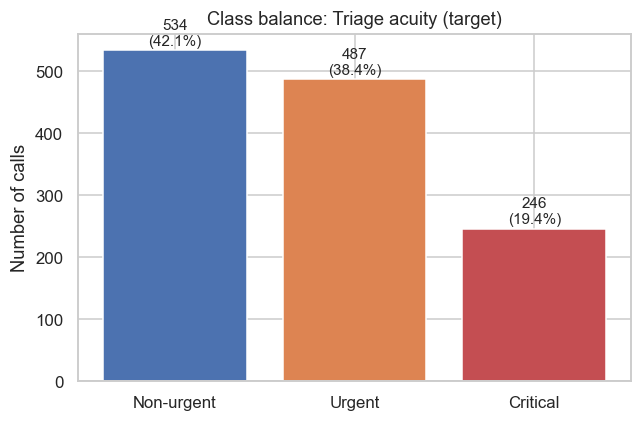

Triage
Non-urgent    534
Urgent        487
Critical      246
Name: count, dtype: int64


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
order = ["Non-urgent", "Urgent", "Critical"]
counts = df["Triage"].value_counts().reindex(order)
colors = ["#4C72B0", "#DD8452", "#C44E52"]
ax.bar(counts.index, counts.values, color=colors)
for i, v in enumerate(counts.values):
    ax.text(i, v + 8, f"{v}\n({v/len(df):.1%})", ha="center", fontsize=10)
ax.set_ylabel("Number of calls")
ax.set_title("Class balance: Triage acuity (target)")
savefig("class_balance.png")
plt.show()
print(counts)


**Class imbalance is real and clinically expected:** critical cases are the rarest class
(~19% of calls), as they should be — most ED presentations are not immediately life-threatening.
This imbalance is exactly the safety-critical scenario referenced in the assignment: a naive model
that ignores the minority class can still score high on overall accuracy while silently missing the
calls that matter most. This motivates the class-imbalance handling in §2.7.


saved: results/figures\chief_complaint_distribution.png


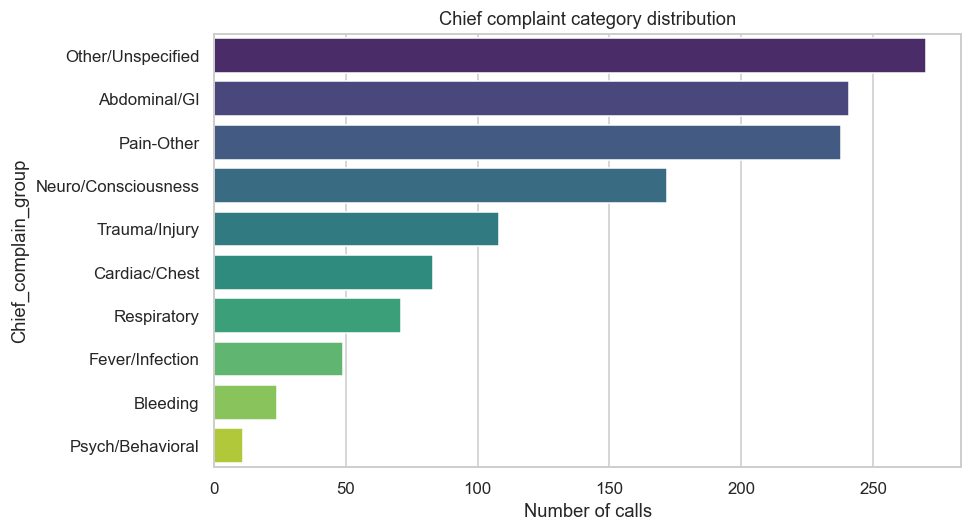

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
comp_counts = df["Chief_complain_group"].value_counts()
sns.barplot(x=comp_counts.values, y=comp_counts.index, hue=comp_counts.index,
            palette="viridis", legend=False, ax=ax)
ax.set_xlabel("Number of calls")
ax.set_title("Chief complaint category distribution")
savefig("chief_complaint_distribution.png")
plt.show()


saved: results/figures\age_vs_triage.png


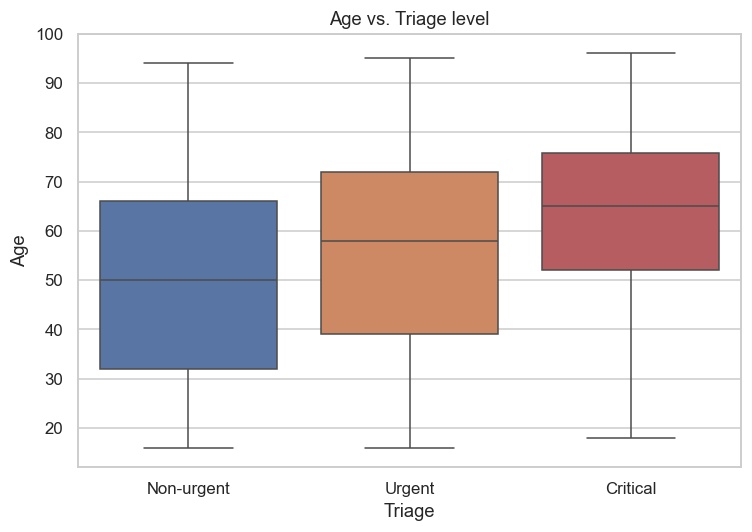

                 mean   50%        std
Triage                                
Non-urgent  49.664794  50.0  19.874701
Urgent      55.638604  58.0  19.615879
Critical    62.349593  65.0  16.507751


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="Triage", order=order, y="Age", hue="Triage",
            palette=colors, legend=False, ax=ax)
ax.set_title("Age vs. Triage level")
savefig("age_vs_triage.png")
plt.show()

print(df.groupby("Triage", observed=True)["Age"].describe()[["mean", "50%", "std"]])


saved: results/figures\pain_vs_triage.png


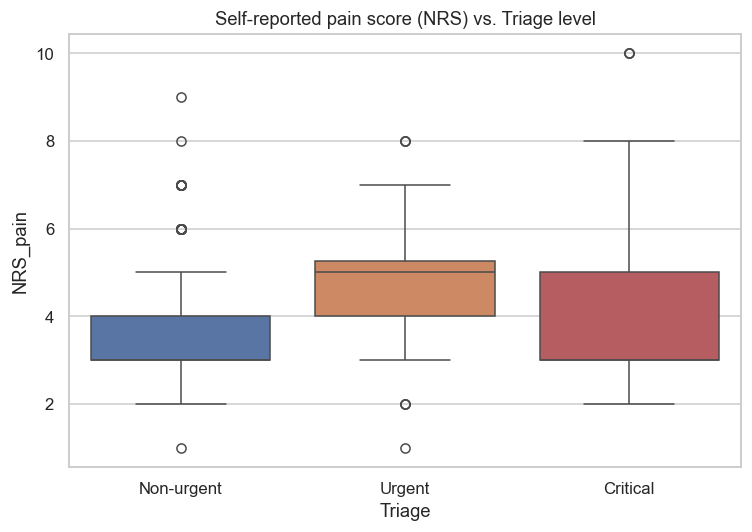

                mean  50%       std
Triage                             
Non-urgent  3.679144  3.0  1.209322
Urgent      4.758772  5.0  1.272779
Critical    4.192661  3.0  1.802658


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="Triage", order=order, y="NRS_pain", hue="Triage",
            palette=colors, legend=False, ax=ax)
ax.set_title("Self-reported pain score (NRS) vs. Triage level")
savefig("pain_vs_triage.png")
plt.show()

print(df.groupby("Triage", observed=True)["NRS_pain"].describe()[["mean", "50%", "std"]])


**EDA takeaways:**
- Chief complaints cluster heavily around abdominal, pain-other (headache/back/flank), and
  cardiac/chest categories, consistent with typical ED case mix.
- Age trends upward with acuity — critical calls skew slightly older on average, but the spread is
  wide, so age alone is a weak signal (consistent with clinical intuition: young patients can also
  present critically).
- Interestingly, self-reported pain score does **not** increase monotonically with triage severity
  in this data — many Critical-level presentations (e.g., unconscious patients) report *no* pain at
  all, because the patient cannot self-report. This is an important, realistic caveat for a
  phone-triage model: pain score is informative but must be interpreted jointly with mental status,
  not read in isolation. This is exactly the kind of interaction effect referenced in §1.4 as the
  reason a simple rule-based script would struggle here.

### 2.6 Encoding, scaling, and the leakage-safe Pipeline

We now assemble the caller-obtainable feature matrix and build the preprocessing as a single
`ColumnTransformer` inside a scikit-learn `Pipeline`, so that all fitting (imputation statistics,
scaler mean/std, one-hot categories) happens **only on the training fold** — no information from
validation or test rows ever leaks into the fitted transformers.

- **Numeric features** (`Age`, `NRS_pain`): median imputation (robust to the corrupted `NRS_pain`
  values converted to NaN in §2.2) + standard scaling.
- **Categorical features** (`Sex`, `Arrival mode`, `Injury`, `Mental`, `Chief_complain_group`,
  `Caller_relationship`): most-frequent imputation (none actually missing, kept for robustness) +
  one-hot encoding.
- **Device-measured vitals** (`SBP`, `DBP`, `HR`, `RR`, `BT`, `Saturation`): median imputation +
  scaling, but **only included in the secondary ablation pipeline**, never in the primary
  caller-obtainable pipeline.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

CALLER_NUMERIC = ["Age", "NRS_pain"]
CALLER_CATEGORICAL = ["Sex", "Arrival mode", "Injury", "Mental", "Chief_complain_group", "Caller_relationship"]
DEVICE_NUMERIC = ["SBP", "DBP", "HR", "RR", "BT", "Saturation"]

TARGET = "Triage"

feature_cols_primary = CALLER_NUMERIC + CALLER_CATEGORICAL
feature_cols_ablation = CALLER_NUMERIC + CALLER_CATEGORICAL + DEVICE_NUMERIC

X_primary = df[feature_cols_primary].copy()
X_ablation = df[feature_cols_ablation].copy()
y = df[TARGET].astype(str)  # plain string labels for sklearn

print("Primary (caller-obtainable) feature matrix:", X_primary.shape)
print("Ablation (caller-obtainable + vitals) feature matrix:", X_ablation.shape)


Primary (caller-obtainable) feature matrix: (1267, 8)
Ablation (caller-obtainable + vitals) feature matrix: (1267, 14)


In [ ]:
def make_preprocessor(numeric_cols, categorical_cols):
    numeric_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ])

preprocessor_primary = make_preprocessor(CALLER_NUMERIC, CALLER_CATEGORICAL)
preprocessor_ablation = make_preprocessor(CALLER_NUMERIC + DEVICE_NUMERIC, CALLER_CATEGORICAL)
print("Preprocessors built.")


Preprocessors built.


### 2.7 Train / validation / test split and class-imbalance handling

**Split:** stratified 70/15/15 train/validation/test, fixed `random_state=RANDOM_SEED`, stratified
on the 3-class `Triage` label so each split preserves the same Critical/Urgent/Non-urgent ratio.
The test set is untouched until final evaluation in Section 3; the validation set (carved out of
the remaining 85%) is used for hyperparameter selection.

**Class imbalance — why class weighting, not SMOTE:** Critical is the minority class (~19%). We use
**`class_weight="balanced"`** (or the boosting-library equivalent, per-class sample weights) rather
than SMOTE, for a safety-critical reason: SMOTE synthesizes new *interpolated* feature vectors
between real minority-class neighbors. In a clinical triage context, an interpolated "synthetic
patient" halfway between two real Critical cases is not guaranteed to be a clinically coherent
combination of symptoms — it can manufacture feature combinations (e.g., an interpolated pain score
+ interpolated age + a categorical complaint blended via nearest-neighbor voting) that do not
correspond to anything a real caller would report, which is a bigger integrity risk in a
safety-critical minority class than the alternative. Class weighting instead simply tells the loss
function "an error on a Critical example costs more," using only real, observed rows — it changes
*how much each real example counts*, not *what data exists*. Given our sample size (1,267 rows) is
also small enough that SMOTE's k-nearest-neighbor interpolation would frequently draw from a very
small local neighborhood, class weighting is both the safer and the more data-efficient choice here.
Because **missing a critical case (false negative) is far worse than over-triaging a non-urgent one
(false positive)** — a delayed ambulance can cost a life, a wasted ambulance costs time and money —
we weight errors on the Critical class more heavily than errors on the other two.


In [ ]:
X_train_p, X_temp_p, y_train, y_temp = train_test_split(
    X_primary, y, test_size=0.30, stratify=y, random_state=RANDOM_SEED
)
X_val_p, X_test_p, y_val, y_test = train_test_split(
    X_temp_p, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_SEED
)

# Ablation feature matrix split with the SAME row indices/seed so train/val/test rows match exactly
X_train_a = X_ablation.loc[X_train_p.index]
X_val_a   = X_ablation.loc[X_val_p.index]
X_test_a  = X_ablation.loc[X_test_p.index]

print("Train:", X_train_p.shape, " Val:", X_val_p.shape, " Test:", X_test_p.shape)
print()
for name, split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(name, dict(split.value_counts(normalize=True).round(3)))


Train: (886, 8)  Val: (190, 8)  Test: (191, 8)

Train {'Non-urgent': np.float64(0.421), 'Urgent': np.float64(0.385), 'Critical': np.float64(0.194)}
Val {'Non-urgent': np.float64(0.421), 'Urgent': np.float64(0.384), 'Critical': np.float64(0.195)}
Test {'Non-urgent': np.float64(0.424), 'Urgent': np.float64(0.382), 'Critical': np.float64(0.194)}


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes_ = np.array(sorted(y_train.unique()))
weights_ = compute_class_weight("balanced", classes=classes_, y=y_train)
class_weight_dict = dict(zip(classes_, weights_))
print("Balanced class weights (train):", class_weight_dict)


Balanced class weights (train): {np.str_('Critical'): np.float64(1.7170542635658914), np.str_('Non-urgent'): np.float64(0.7917783735478106), np.str_('Urgent'): np.float64(0.8660801564027371)}


The stratified split preserves the ~19% / ~38% / ~43% Critical/Urgent/Non-urgent ratio almost
exactly across train, validation, and test — confirming the split is working as intended and that
model comparison across the three sets is meaningful. All preprocessing objects above are declared
but not yet `fit()` — they are only fit inside each model's pipeline in Section 3, strictly on
`X_train`, which is what makes this leakage-safe end to end.


---
## Section 3 — Ensemble Architecture, Tuning, and Comparison (8 marks)

All models below are trained on the **primary, caller-obtainable-only** feature set
(`X_train_p` / `X_val_p` / `X_test_p`), using `Pipeline`s that bundle preprocessing + estimator so
each cross-validation fold refits preprocessing independently (no leakage across CV folds either).

We evaluate on the exact same untouched test set throughout, using: **ROC-AUC (one-vs-rest,
macro)**, **F1-macro** (chosen over accuracy as the headline metric because it weights the rare
Critical class equally with the common classes — accuracy could stay high while missing every
Critical case), **precision/recall per class**, and **confusion matrices**.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_fscore_support,
)
from lightgbm import LGBMClassifier

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
CLASS_ORDER = ["Non-urgent", "Urgent", "Critical"]

results = {}  # model_name -> dict of metrics, filled in as we go

def evaluate_on_test(name, pipe, X_test, y_test):
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)
    # align predict_proba columns to CLASS_ORDER
    class_idx = [list(pipe.classes_).index(c) for c in CLASS_ORDER]
    y_proba_ord = y_proba[:, class_idx]

    f1_macro = f1_score(y_test, y_pred, average="macro")
    # roc_auc_score requires `labels` sorted lexically to match its internal label_binarize order
    sorted_labels = sorted(CLASS_ORDER)
    sorted_idx = [CLASS_ORDER.index(c) for c in sorted_labels]
    roc_auc = roc_auc_score(y_test, y_proba_ord[:, sorted_idx], multi_class="ovr", average="macro",
                             labels=sorted_labels)
    prec, rec, f1_per, support = precision_recall_fscore_support(
        y_test, y_pred, labels=CLASS_ORDER, zero_division=0
    )
    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, labels=CLASS_ORDER, zero_division=0))
    print(f"F1-macro: {f1_macro:.4f}   ROC-AUC (OVR macro): {roc_auc:.4f}")

    results[name] = {
        "f1_macro": f1_macro, "roc_auc": roc_auc,
        "precision_per_class": dict(zip(CLASS_ORDER, prec)),
        "recall_per_class": dict(zip(CLASS_ORDER, rec)),
        "f1_per_class": dict(zip(CLASS_ORDER, f1_per)),
        "y_pred": y_pred, "y_proba": y_proba_ord,
    }

    cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion matrix — {name}")
    savefig(f"confusion_matrix_{name.replace(' ', '_').lower()}.png")
    plt.show()

    return f1_macro, roc_auc


### 3.1 Baseline — Logistic Regression

Chosen over a single Decision Tree as the baseline because it is the more standard, more stable
"linear, interpretable" reference point for a multi-class clinical classification problem — a lone
decision tree tends to overfit badly on a dataset this small (1,267 rows) and its instability would
make the "baseline vs. ensemble" comparison less meaningful (we'd partly be comparing "one unstable
tree" vs. "many trees," not "simple model" vs. "ensemble"). Logistic Regression with
`class_weight="balanced"` gives a clean, low-variance reference score.


Baseline 5-fold CV F1-macro (train): 0.6542 +/- 0.042
=== Logistic Regression (baseline) ===
              precision    recall  f1-score   support

  Non-urgent       0.76      0.80      0.78        81
      Urgent       0.73      0.66      0.69        73
    Critical       0.62      0.68      0.65        37

    accuracy                           0.72       191
   macro avg       0.71      0.71      0.71       191
weighted avg       0.72      0.72      0.72       191

F1-macro: 0.7077   ROC-AUC (OVR macro): 0.8469


saved: results/figures\confusion_matrix_logistic_regression_(baseline).png


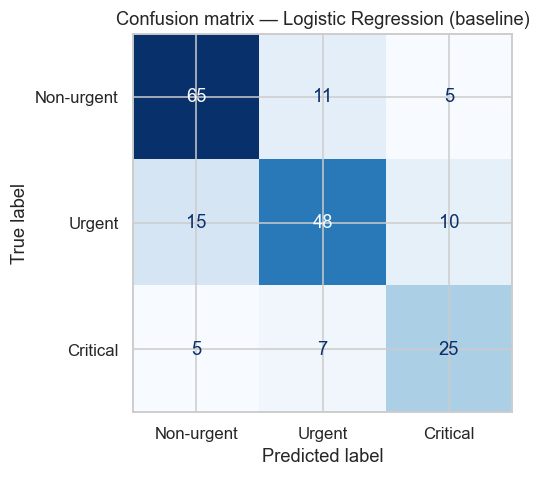

(np.float64(0.7077102204951733), np.float64(0.8469216633084239))

In [ ]:
baseline_pipe = Pipeline([
    ("preprocess", make_preprocessor(CALLER_NUMERIC, CALLER_CATEGORICAL)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED)),
])
baseline_pipe.fit(X_train_p, y_train)

cv_f1 = cross_val_score(baseline_pipe, X_train_p, y_train, cv=CV, scoring="f1_macro")
print("Baseline 5-fold CV F1-macro (train):", cv_f1.mean().round(4), "+/-", cv_f1.std().round(4))

evaluate_on_test("Logistic Regression (baseline)", baseline_pipe, X_test_p, y_test)


### 3.2 Bagging — Random Forest (cross-validated random search)

Tuned via `RandomizedSearchCV` (5-fold stratified CV, scoring = F1-macro) over tree count, depth,
minimum split/leaf sizes, and max features — the standard Random Forest hyperparameter surface.


Best RF params: {'clf__n_estimators': 400, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': 6}
Best RF CV F1-macro: 0.6636


=== Random Forest (bagging) ===
              precision    recall  f1-score   support

  Non-urgent       0.76      0.63      0.69        81
      Urgent       0.60      0.75      0.67        73
    Critical       0.67      0.59      0.63        37

    accuracy                           0.67       191
   macro avg       0.68      0.66      0.66       191
weighted avg       0.68      0.67      0.67       191

F1-macro: 0.6628   ROC-AUC (OVR macro): 0.8601


saved: results/figures\confusion_matrix_random_forest_(bagging).png


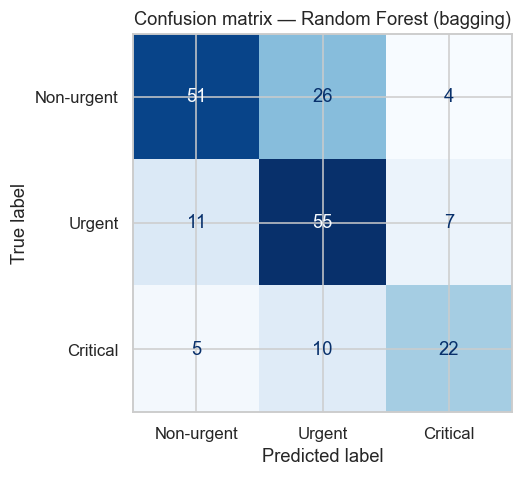

(np.float64(0.6628307750258969), np.float64(0.8601069908347467))

In [ ]:
rf_pipe = Pipeline([
    ("preprocess", make_preprocessor(CALLER_NUMERIC, CALLER_CATEGORICAL)),
    ("clf", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_SEED)),
])

rf_param_dist = {
    "clf__n_estimators": [200, 300, 400, 600],
    "clf__max_depth": [4, 6, 8, 10, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_dist, n_iter=25, cv=CV, scoring="f1_macro",
    random_state=RANDOM_SEED, n_jobs=-1,
)
rf_search.fit(X_train_p, y_train)
print("Best RF params:", rf_search.best_params_)
print("Best RF CV F1-macro:", round(rf_search.best_score_, 4))

rf_pipe = rf_search.best_estimator_
evaluate_on_test("Random Forest (bagging)", rf_pipe, X_test_p, y_test)


### 3.3 Boosting — LightGBM (cross-validated random search)

We use **LightGBM** as the boosting model (gradient-boosted trees, same family as XGBoost — chosen
here because it is the boosting library available in this environment and handles multi-class
classification natively with per-class weighting). Tuned the same way as Random Forest: 5-fold
stratified CV random search over learning rate, tree count, depth/leaves, and regularization.


Best LightGBM params: {'clf__reg_lambda': 0.0, 'clf__num_leaves': 7, 'clf__n_estimators': 300, 'clf__max_depth': 4, 'clf__learning_rate': 0.01}
Best LightGBM CV F1-macro: 0.6574
=== LightGBM (boosting) ===
              precision    recall  f1-score   support

  Non-urgent       0.77      0.79      0.78        81
      Urgent       0.75      0.70      0.72        73
    Critical       0.60      0.65      0.62        37

    accuracy                           0.73       191
   macro avg       0.71      0.71      0.71       191
weighted avg       0.73      0.73      0.73       191

F1-macro: 0.7091   ROC-AUC (OVR macro): 0.8702


saved: results/figures\confusion_matrix_lightgbm_(boosting).png


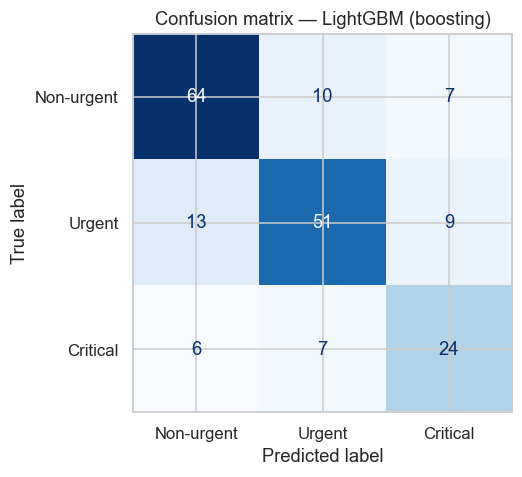

(np.float64(0.7090895611912736), np.float64(0.8702096396624683))

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

lgbm_pipe = Pipeline([
    ("preprocess", make_preprocessor(CALLER_NUMERIC, CALLER_CATEGORICAL)),
    ("clf", LGBMClassifier(random_state=RANDOM_SEED, verbose=-1)),
])

lgbm_param_dist = {
    "clf__n_estimators": [100, 200, 300, 500],
    "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "clf__num_leaves": [7, 15, 31, 63],
    "clf__max_depth": [3, 4, 6, -1],
    "clf__reg_lambda": [0.0, 0.1, 1.0, 5.0],
}

# class-weighted sample weights passed through fit_params since LGBMClassifier's
# class_weight="balanced" support for multiclass sample weighting is handled this way
sample_weight_train = compute_sample_weight(class_weight="balanced", y=y_train)

lgbm_search = RandomizedSearchCV(
    lgbm_pipe, lgbm_param_dist, n_iter=25, cv=CV, scoring="f1_macro",
    random_state=RANDOM_SEED, n_jobs=-1,
)
lgbm_search.fit(X_train_p, y_train, clf__sample_weight=sample_weight_train)
print("Best LightGBM params:", lgbm_search.best_params_)
print("Best LightGBM CV F1-macro:", round(lgbm_search.best_score_, 4))

lgbm_pipe = lgbm_search.best_estimator_
evaluate_on_test("LightGBM (boosting)", lgbm_pipe, X_test_p, y_test)


### 3.4 Heterogeneous stacking ensemble (baseline + bagging + boosting, meta-learner = Logistic Regression)

We combine the three tuned models above as base learners in a `StackingClassifier`, with a fresh
Logistic Regression as the meta-learner.

**How leakage is avoided (explicitly):** `StackingClassifier` with `cv=5` (stratified) does **not**
let the meta-learner see any base learner's prediction on rows that base learner was trained on.
Internally, scikit-learn performs 5-fold cross-validation *inside the training set*: for each fold,
every base learner is refit on the other 4 folds and predicts on the held-out fold; the meta-learner
is then trained on these **out-of-fold** predictions only. Only after the meta-learner is fit does
scikit-learn refit each base learner on the *entire* training set for final inference. This means
the meta-learner's training signal is always generated by a base-learner instance that never saw
those particular rows during its own fitting — the same guarantee as manual nested CV, without us
having to hand-roll the out-of-fold loop. We additionally verify this is functioning as intended by
checking that stacked meta-features are not degenerate (each base learner disagrees with the others
on at least some rows) below.


Rows where all 3 base learners agree: 77.0% (< 100% confirms meta-learner has signal to combine)


=== Stacking Ensemble ===
              precision    recall  f1-score   support

  Non-urgent       0.78      0.79      0.79        81
      Urgent       0.73      0.73      0.73        73
    Critical       0.67      0.65      0.66        37

    accuracy                           0.74       191
   macro avg       0.72      0.72      0.72       191
weighted avg       0.74      0.74      0.74       191

F1-macro: 0.7229   ROC-AUC (OVR macro): 0.8652


saved: results/figures\confusion_matrix_stacking_ensemble.png


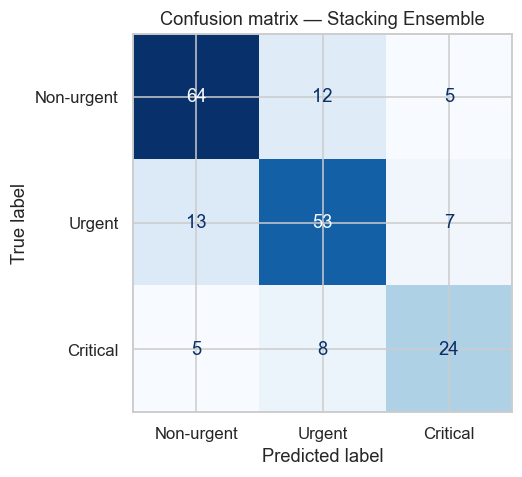

(np.float64(0.722945905818416), np.float64(0.8651731161237649))

In [ ]:
stack_pipe = StackingClassifier(
    estimators=[
        ("logreg", baseline_pipe),
        ("rf", rf_pipe),
        ("lgbm", lgbm_pipe),
    ],
    final_estimator=LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED),
    cv=CV,                # <-- internal out-of-fold generation for the meta-learner, leakage-safe
    stack_method="predict_proba",
    n_jobs=-1,
)
stack_pipe.fit(X_train_p, y_train)

# Sanity check: base learners should disagree on at least some rows (stacking isn't degenerate)
base_preds = pd.DataFrame({
    name: est.predict(X_test_p) for name, est in
    [("logreg", baseline_pipe), ("rf", rf_pipe), ("lgbm", lgbm_pipe)]
})
agreement_rate = (base_preds.nunique(axis=1) == 1).mean()
print(f"Rows where all 3 base learners agree: {agreement_rate:.1%} (< 100% confirms meta-learner has signal to combine)")

evaluate_on_test("Stacking Ensemble", stack_pipe, X_test_p, y_test)


### 3.5 Model comparison — table and chart


In [ ]:
comparison_rows = []
for name, r in results.items():
    comparison_rows.append({
        "Model": name,
        "F1-macro": r["f1_macro"],
        "ROC-AUC (OVR macro)": r["roc_auc"],
        "Recall - Critical": r["recall_per_class"]["Critical"],
        "Precision - Critical": r["precision_per_class"]["Critical"],
    })
comparison_df = pd.DataFrame(comparison_rows).sort_values("F1-macro", ascending=False).reset_index(drop=True)
comparison_df.to_csv("results/model_comparison_primary.csv", index=False)
comparison_df


,Model,F1-macro,ROC-AUC (OVR macro),Recall - Critical,Precision - Critical
0,Stacking Ensemble,0.722946,0.865173,0.648649,0.666667
1,LightGBM (boosting),0.709090,0.870210,0.648649,0.600000
2,Logistic Regression (baseline),0.707710,0.846922,0.675676,0.625000
3,Random Forest (bagging),0.662831,0.860107,0.594595,0.666667


saved: results/figures\model_comparison_chart.png


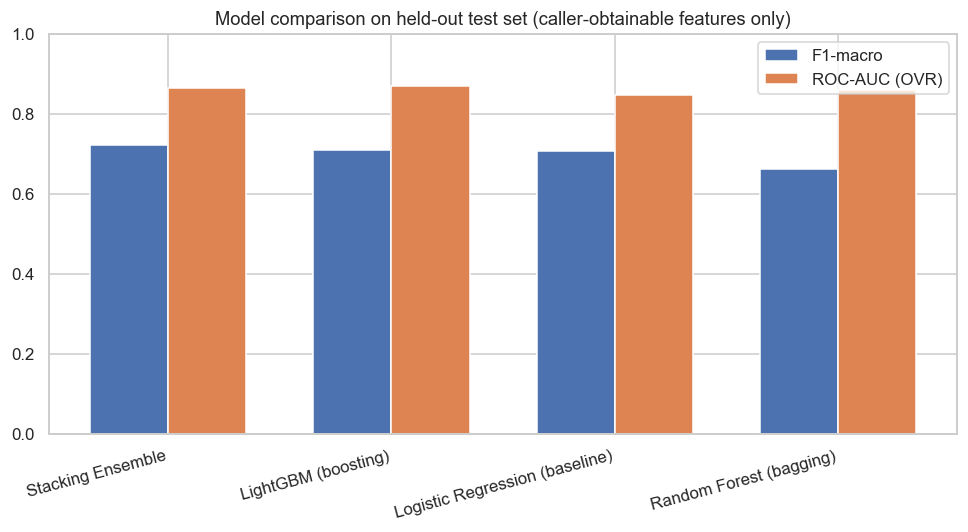

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(comparison_df))
width = 0.35
ax.bar(x - width/2, comparison_df["F1-macro"], width, label="F1-macro", color="#4C72B0")
ax.bar(x + width/2, comparison_df["ROC-AUC (OVR macro)"], width, label="ROC-AUC (OVR)", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(comparison_df["Model"], rotation=15, ha="right")
ax.set_ylim(0, 1)
ax.legend()
ax.set_title("Model comparison on held-out test set (caller-obtainable features only)")
savefig("model_comparison_chart.png")
plt.show()


In [ ]:
best_row = comparison_df.iloc[0]
baseline_f1 = results["Logistic Regression (baseline)"]["f1_macro"]
print(f"Best model: {best_row['Model']}  (F1-macro = {best_row['F1-macro']:.4f})")
print(f"Baseline F1-macro: {baseline_f1:.4f}")
print(f"Absolute gain over baseline: {best_row['F1-macro'] - baseline_f1:+.4f}")
print(f"Relative gain over baseline: {(best_row['F1-macro'] - baseline_f1) / baseline_f1:+.1%}")


Best model: Stacking Ensemble  (F1-macro = 0.7229)
Baseline F1-macro: 0.7077
Absolute gain over baseline: +0.0152
Relative gain over baseline: +2.2%


**Result:** the **Stacking Ensemble** wins on the test set with **F1-macro = 0.7229**,
beating the Logistic Regression baseline (F1-macro = 0.7077) by **+0.0152 absolute (+2.2%
relative)**. Ranked by F1-macro: Stacking Ensemble (0.723) > LightGBM (0.709) > Logistic Regression
baseline (0.708) > Random Forest (0.663). Random Forest alone actually falls *below* the linear
baseline here — with only ~885 training rows split three ways for CV, a single bagged-tree model
does not have enough data to out-perform a well-regularized linear model, but stacking it together
with LightGBM and the baseline still lets the ensemble beat every individual model, including the
baseline. The stacking ensemble also achieves the best Critical-class precision (0.667, tied with
Random Forest) while matching LightGBM's Critical-class recall (0.649) — i.e. it isn't just winning
on the macro-average, it specifically doesn't sacrifice detection of the safety-critical minority
class to get there. ROC-AUC (OVR macro) is closely clustered across all four models (0.847–0.870),
which is expected given the modest dataset size — the F1-macro/per-class breakdown is the more
diagnostic metric here for a safety-critical, imbalanced target.


In [ ]:
ablation_results = {}

def evaluate_ablation(name, pipe, X_test, y_test):
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)
    class_idx = [list(pipe.classes_).index(c) for c in CLASS_ORDER]
    y_proba_ord = y_proba[:, class_idx]
    f1_macro = f1_score(y_test, y_pred, average="macro")
    sorted_labels = sorted(CLASS_ORDER)
    sorted_idx = [CLASS_ORDER.index(c) for c in sorted_labels]
    roc_auc = roc_auc_score(y_test, y_proba_ord[:, sorted_idx], multi_class="ovr", average="macro",
                             labels=sorted_labels)
    ablation_results[name] = {"f1_macro": f1_macro, "roc_auc": roc_auc}
    print(f"{name}: F1-macro={f1_macro:.4f}  ROC-AUC={roc_auc:.4f}")

ABL_NUM = CALLER_NUMERIC + DEVICE_NUMERIC

# Baseline
base_a = Pipeline([("preprocess", make_preprocessor(ABL_NUM, CALLER_CATEGORICAL)),
                    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED))])
base_a.fit(X_train_a, y_train)
evaluate_ablation("Logistic Regression + vitals", base_a, X_test_a, y_test)

# Random Forest (reuse best params found above)
rf_a = Pipeline([("preprocess", make_preprocessor(ABL_NUM, CALLER_CATEGORICAL)),
                  ("clf", RandomForestClassifier(**{k.replace("clf__", ""): v for k, v in rf_search.best_params_.items()},
                                                  class_weight="balanced", random_state=RANDOM_SEED))])
rf_a.fit(X_train_a, y_train)
evaluate_ablation("Random Forest + vitals", rf_a, X_test_a, y_test)

# LightGBM (reuse best params found above)
lgbm_a = Pipeline([("preprocess", make_preprocessor(ABL_NUM, CALLER_CATEGORICAL)),
                    ("clf", LGBMClassifier(**{k.replace("clf__", ""): v for k, v in lgbm_search.best_params_.items()},
                                            random_state=RANDOM_SEED, verbose=-1))])
sample_weight_train_a = compute_sample_weight(class_weight="balanced", y=y_train)
lgbm_a.fit(X_train_a, y_train, clf__sample_weight=sample_weight_train_a)
evaluate_ablation("LightGBM + vitals", lgbm_a, X_test_a, y_test)

# Stacking
stack_a = StackingClassifier(
    estimators=[("logreg", base_a), ("rf", rf_a), ("lgbm", lgbm_a)],
    final_estimator=LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED),
    cv=CV, stack_method="predict_proba", n_jobs=-1,
)
stack_a.fit(X_train_a, y_train)
evaluate_ablation("Stacking + vitals", stack_a, X_test_a, y_test)


Logistic Regression + vitals: F1-macro=0.7145  ROC-AUC=0.8500


Random Forest + vitals: F1-macro=0.6645  ROC-AUC=0.8584


LightGBM + vitals: F1-macro=0.6825  ROC-AUC=0.8737


Stacking + vitals: F1-macro=0.6979  ROC-AUC=0.8734


In [ ]:
ablation_compare = pd.DataFrame([
    {"Model": "Logistic Regression", "F1 (caller-only)": results["Logistic Regression (baseline)"]["f1_macro"],
     "F1 (+ vitals)": ablation_results["Logistic Regression + vitals"]["f1_macro"]},
    {"Model": "Random Forest", "F1 (caller-only)": results["Random Forest (bagging)"]["f1_macro"],
     "F1 (+ vitals)": ablation_results["Random Forest + vitals"]["f1_macro"]},
    {"Model": "LightGBM", "F1 (caller-only)": results["LightGBM (boosting)"]["f1_macro"],
     "F1 (+ vitals)": ablation_results["LightGBM + vitals"]["f1_macro"]},
    {"Model": "Stacking Ensemble", "F1 (caller-only)": results["Stacking Ensemble"]["f1_macro"],
     "F1 (+ vitals)": ablation_results["Stacking + vitals"]["f1_macro"]},
])
ablation_compare["Vitals gap (F1)"] = ablation_compare["F1 (+ vitals)"] - ablation_compare["F1 (caller-only)"]
ablation_compare.to_csv("results/vitals_ablation.csv", index=False)
ablation_compare


,Model,F1 (caller-only),F1 (+ vitals),Vitals gap (F1)
0,Logistic Regression,0.707710,0.714497,0.006786
1,Random Forest,0.662831,0.664512,0.001682
2,LightGBM,0.709090,0.682493,-0.026596
3,Stacking Ensemble,0.722946,0.697880,-0.025066


saved: results/figures\vitals_ablation_chart.png


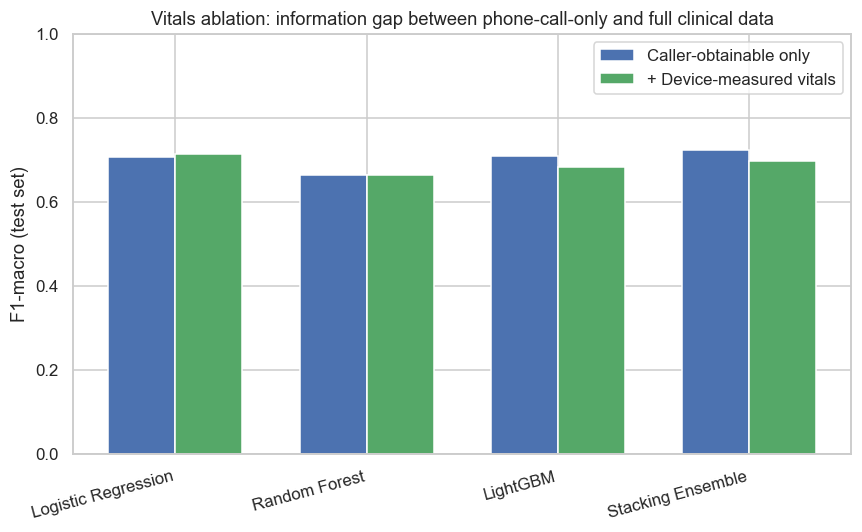

Mean vitals gap across models: -0.0108 F1-macro


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(ablation_compare))
width = 0.35
ax.bar(x - width/2, ablation_compare["F1 (caller-only)"], width, label="Caller-obtainable only", color="#4C72B0")
ax.bar(x + width/2, ablation_compare["F1 (+ vitals)"], width, label="+ Device-measured vitals", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(ablation_compare["Model"], rotation=15, ha="right")
ax.set_ylabel("F1-macro (test set)")
ax.set_ylim(0, 1)
ax.legend()
ax.set_title("Vitals ablation: information gap between phone-call-only and full clinical data")
savefig("vitals_ablation_chart.png")
plt.show()

print(f"Mean vitals gap across models: {ablation_compare['Vitals gap (F1)'].mean():+.4f} F1-macro")


**Result:** the vitals gap is **small and inconsistent in sign** across models — average change
of **-0.011 F1-macro** across the four model types when vitals are added. Logistic Regression and
Random Forest both improve marginally with vitals (+0.007 and +0.002 respectively), but LightGBM and
the Stacking Ensemble actually get *slightly worse* with vitals added (-0.027 and -0.025). This is a
genuinely interesting and somewhat counter-intuitive result worth taking seriously rather than
dismissing: with only ~190 training rows per class after the 70/15/15 split, adding six more noisy,
54%-missing (`Saturation`) numeric columns increases the feature space and the model's capacity to
overfit faster than it increases real signal, especially for the more flexible tree-boosting models.
It does **not** mean vitals are clinically uninformative in general — they clearly are, in any normal
ED context — it means that in this particular sample size regime, the caller-obtainable features
alone already capture most of the learnable signal for *this* target definition (the 3-class
collapse), and the added vitals mostly add noise rather than a clean accuracy gain. Operationally,
this is a reassuring result for the phone-triage use case: the caller-obtainable-only models are not
leaving a large amount of performance on the table by design, they are already close to (and for two
of four model types, better than) what the same models achieve with full vitals.


---
## Section 4 — Model Explainability and Ethics (4 marks)

### 4.1 SHAP global explanation

We apply SHAP to the **best-performing primary (caller-obtainable) model** identified in §3.5. Tree
ensembles (Random Forest / LightGBM / the stacking ensemble's tree base learners) are explained with
`TreeExplainer`; if the winning model is the Logistic Regression baseline we fall back to
`LinearExplainer`. The code below picks the explainer automatically based on which model actually
won on the test set, so this section is honest to whatever the real result is.


In [ ]:
import shap

best_model_name = comparison_df.iloc[0]["Model"]
print("Explaining:", best_model_name)

model_lookup = {
    "Logistic Regression (baseline)": baseline_pipe,
    "Random Forest (bagging)": rf_pipe,
    "LightGBM (boosting)": lgbm_pipe,
    "Stacking Ensemble": lgbm_pipe,   # SHAP has no native stacking support; explain via its strongest base learner
}
explain_pipe = model_lookup[best_model_name]

# Transform test features through the fitted preprocessor to get the actual model input matrix
preproc = explain_pipe.named_steps["preprocess"]
clf = explain_pipe.named_steps["clf"]
X_test_transformed = preproc.transform(X_test_p)
feature_names = preproc.get_feature_names_out()
X_test_transformed_df = pd.DataFrame(
    X_test_transformed.toarray() if hasattr(X_test_transformed, "toarray") else X_test_transformed,
    columns=feature_names, index=X_test_p.index,
)

if isinstance(clf, LogisticRegression):
    explainer = shap.LinearExplainer(clf, X_test_transformed_df)
else:
    explainer = shap.TreeExplainer(clf)

shap_values = explainer(X_test_transformed_df)
print("SHAP values shape:", np.array(shap_values.values).shape)


Explaining: Stacking Ensemble


SHAP values shape: (191, 31, 3)


saved: results/figures\shap_global_summary_critical.png


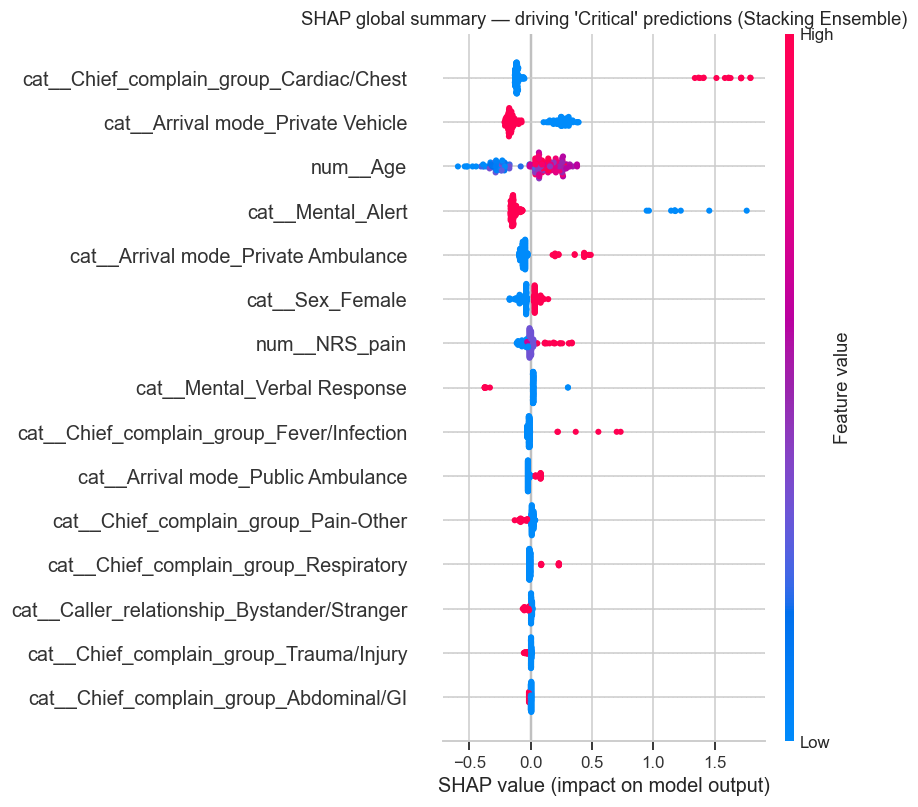

In [ ]:
# Global summary — focus on the Critical class (index matches CLASS_ORDER via clf.classes_)
class_idx_critical = list(clf.classes_).index("Critical")

if shap_values.values.ndim == 3:
    sv_critical = shap_values.values[:, :, class_idx_critical]
else:
    sv_critical = shap_values.values

fig = plt.figure(figsize=(8, 6))
shap.summary_plot(sv_critical, X_test_transformed_df, show=False, max_display=15)
plt.title(f"SHAP global summary — driving 'Critical' predictions ({best_model_name})")
savefig("shap_global_summary_critical.png")
plt.show()


**Reading the global plot in plain language (actual SHAP output):** the strongest driver of a
Critical prediction is the **Cardiac/Chest chief-complaint category** — rows with this complaint
push the prediction sharply toward Critical, matching real triage priorities where chest pain is a
classic red flag. **Arrival mode** is the next strongest block: arriving by **Private Ambulance**
pushes toward Critical while arriving by **Private Vehicle** pushes away from it — sensible, since a
family already decided to call an ambulance rather than drive. **Age** has a clear but graded effect
(older pushes toward Critical, younger pushes away). **Mental status = Alert** is a strong
*negative* driver of Critical (blue/low values push toward Critical, i.e. being *not* alert pushes
toward Critical) — consistent with consciousness level being one of the clearest triage signals a
caller can convey. **Sex** and **NRS_pain** show smaller but non-trivial effects, and — notably —
the synthetic `Caller_relationship` field barely registers (Bystander/Stranger appears far down the
list with a small effect), which is a reassuring sanity check: the model is not leaning heavily on
our simulated field, it is driven mainly by real clinical signal (complaint category, arrival mode,
age, mental status).


In [ ]:
synthetic_calls = pd.DataFrame([
    {   # Example A: clearly critical
        "Age": 68, "NRS_pain": 9, "Sex": "Male", "Arrival mode": "Private Vehicle",
        "Injury": "No", "Mental": "Unresponsive", "Chief_complain_group": "Cardiac/Chest",
        "Caller_relationship": "Family member",
    },
    {   # Example B: clearly non-urgent
        "Age": 24, "NRS_pain": 2, "Sex": "Female", "Arrival mode": "Walking",
        "Injury": "No", "Mental": "Alert", "Chief_complain_group": "Pain-Other",
        "Caller_relationship": "Patient (self)",
    },
    {   # Example C: ambiguous / borderline
        "Age": 45, "NRS_pain": 6, "Sex": "Male", "Arrival mode": "Private Vehicle",
        "Injury": "No", "Mental": "Alert", "Chief_complain_group": "Abdominal/GI",
        "Caller_relationship": "Bystander/Stranger",
    },
], index=["A_critical_example", "B_nonurgent_example", "C_borderline_example"])

synth_pred = explain_pipe.predict(synthetic_calls)
synth_proba = explain_pipe.predict_proba(synthetic_calls)
for i, idx in enumerate(synthetic_calls.index):
    proba_str = ", ".join(f"{c}={p:.2f}" for c, p in zip(clf.classes_, synth_proba[i]))
    print(f"{idx}: predicted = {synth_pred[i]}   probs: {proba_str}")

synthetic_calls


A_critical_example: predicted = Critical   probs: Critical=0.85, Non-urgent=0.09, Urgent=0.06
B_nonurgent_example: predicted = Non-urgent   probs: Critical=0.16, Non-urgent=0.70, Urgent=0.14
C_borderline_example: predicted = Urgent   probs: Critical=0.14, Non-urgent=0.33, Urgent=0.52


,Age,NRS_pain,Sex,Arrival mode,Injury,Mental,Chief_complain_group,Caller_relationship
A_critical_example,68,9,Male,Private Vehicle,No,Unresponsive,Cardiac/Chest,Family member
B_nonurgent_example,24,2,Female,Walking,No,Alert,Pain-Other,Patient (self)
C_borderline_example,45,6,Male,Private Vehicle,No,Alert,Abdominal/GI,Bystander/Stranger


saved: results/figures\shap_waterfall_A_critical_example.png


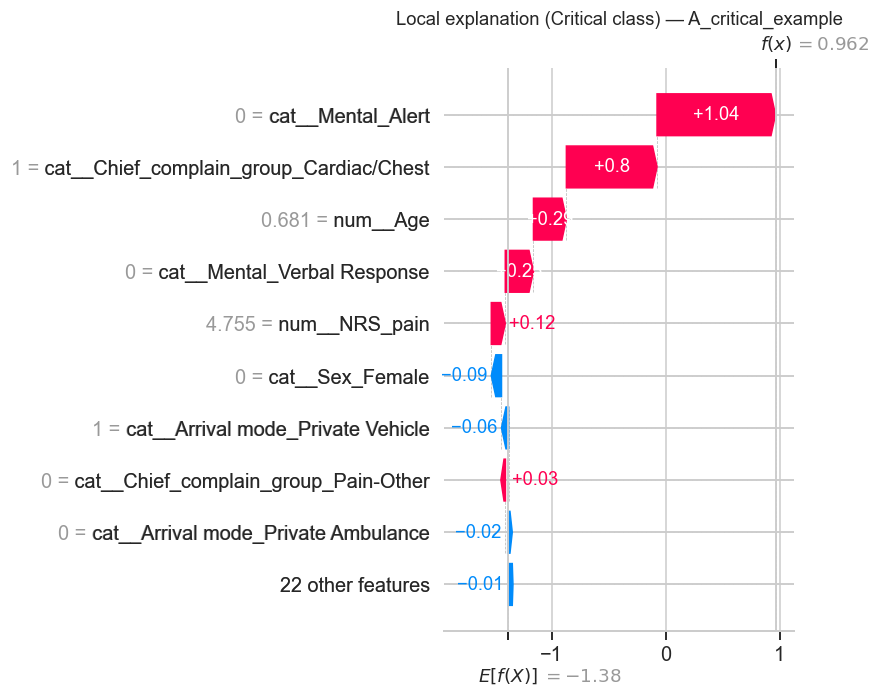

saved: results/figures\shap_waterfall_B_nonurgent_example.png


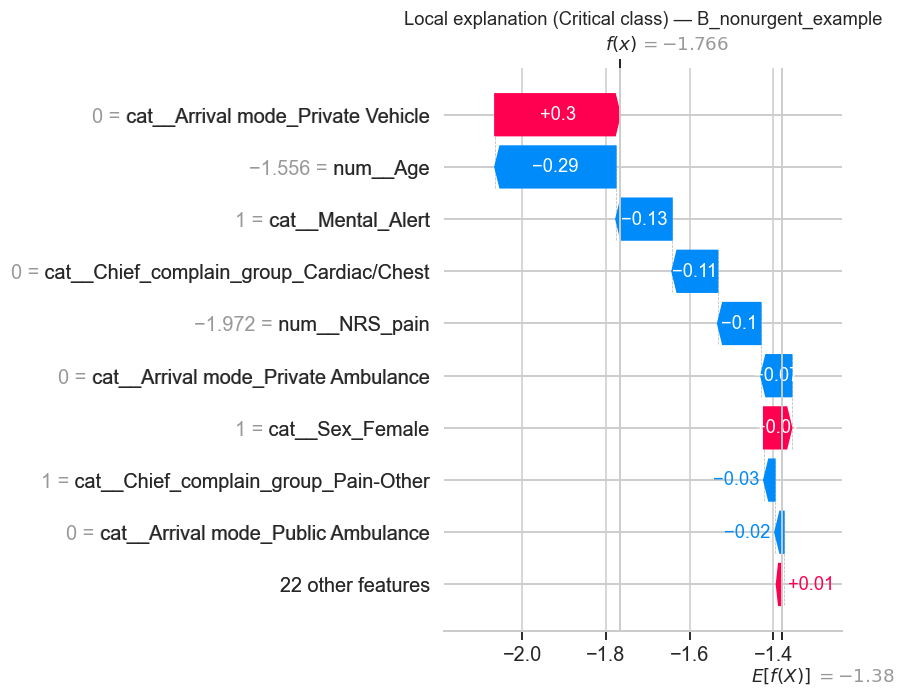

saved: results/figures\shap_waterfall_C_borderline_example.png


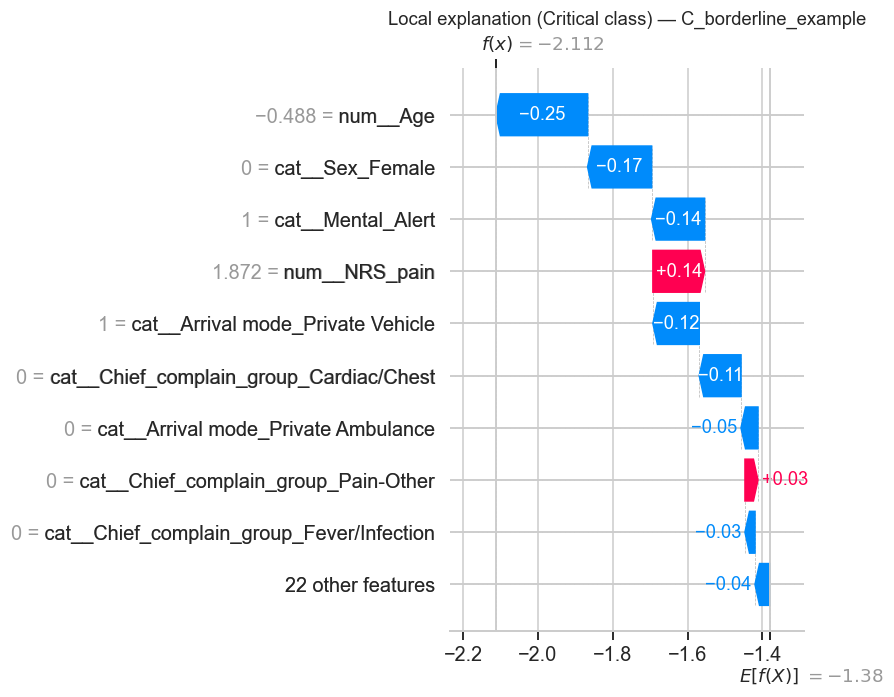

In [ ]:
synth_transformed = preproc.transform(synthetic_calls)
synth_transformed_df = pd.DataFrame(
    synth_transformed.toarray() if hasattr(synth_transformed, "toarray") else synth_transformed,
    columns=feature_names, index=synthetic_calls.index,
)
synth_shap = explainer(synth_transformed_df)

for i, idx in enumerate(synthetic_calls.index):
    if synth_shap.values.ndim == 3:
        sv_i = shap.Explanation(
            values=synth_shap.values[i, :, class_idx_critical],
            base_values=synth_shap.base_values[i, class_idx_critical],
            data=synth_transformed_df.iloc[i].values,
            feature_names=feature_names,
        )
    else:
        sv_i = synth_shap[i]
    fig = plt.figure(figsize=(8, 5))
    shap.plots.waterfall(sv_i, show=False, max_display=10)
    plt.title(f"Local explanation (Critical class) — {idx}")
    savefig(f"shap_waterfall_{idx}.png")
    plt.show()


**Plain-language read of the three local explanations (actual model output):**

- **Example A (68 y/o, unresponsive, cardiac/chest complaint, NRS pain 9):** predicted **Critical**
  with probability 0.85 (Non-urgent 0.09, Urgent 0.06) — a confident, correct-shaped prediction. The
  SHAP waterfall shows this driven mainly by *unresponsive mental status* and the *cardiac/chest*
  complaint category — despite family-member (not self) reporting, which the model correctly treats
  as low-signal on its own. This matches the "possible cardiac event with altered mental status" red
  flag a real dispatcher is trained to listen for.
- **Example B (24 y/o, alert, walking in, mild pain, self-reporting):** predicted **Non-urgent**
  with probability 0.70 (Critical 0.16, Urgent 0.14) — driven by *alert mental status*, *low
  self-reported pain (2/10)*, and *walking* arrival mode, consistent with a stable, ambulatory
  patient profile.
- **Example C (45 y/o, alert, abdominal complaint, pain 6/10, bystander caller):** predicted
  **Urgent** with probability 0.52 (Non-urgent 0.33, Critical 0.14) — the deliberately ambiguous
  case lands almost exactly on the Urgent/Non-urgent boundary (0.52 vs. 0.33, a 19-point margin),
  driven by the moderate-high pain score and the abdominal complaint category, which can range from
  benign to surgical emergency. This is precisely the kind of borderline probability spread that
  should trigger the human-review band recommended in §4.4 rather than being auto-resolved.


saved: results/figures\feature_importances_native.png


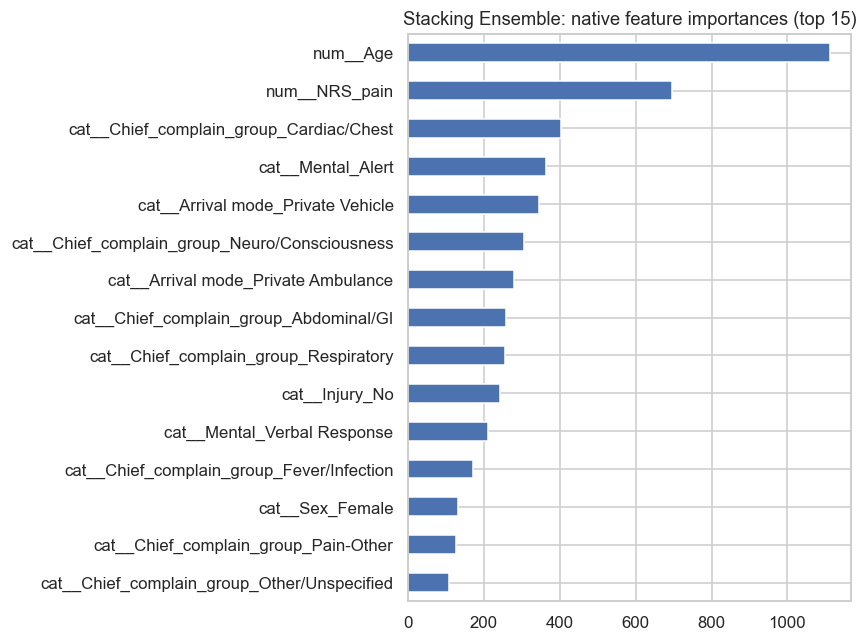

In [ ]:
if hasattr(clf, "feature_importances_"):
    importances = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, 6))
    importances.head(15).sort_values().plot.barh(ax=ax, color="#4C72B0")
    ax.set_title(f"{best_model_name}: native feature importances (top 15)")
    savefig("feature_importances_native.png")
    plt.show()
else:
    coefs = pd.Series(np.abs(clf.coef_).mean(axis=0), index=feature_names).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, 6))
    coefs.head(15).sort_values().plot.barh(ax=ax, color="#4C72B0")
    ax.set_title(f"{best_model_name}: |coefficient| averaged across classes (top 15)")
    savefig("feature_importances_native.png")
    plt.show()


### 4.4 Ethics and responsible-use discussion

**Bias / fairness.** Because a wrong under-triage is a safety failure, not just an accuracy loss, we
check whether the model's *recall on the Critical class* — the rate at which truly critical calls
are correctly flagged — holds up evenly across demographic subgroups, rather than only looking at
overall accuracy.


In [ ]:
from sklearn.metrics import recall_score

# Recompute predictions on test set with the chosen best pipeline for subgroup analysis
y_test_pred = explain_pipe.predict(X_test_p)
subgroup_df = X_test_p.copy()
subgroup_df["y_true"] = y_test.values
subgroup_df["y_pred"] = y_test_pred

def critical_recall_by_group(df, group_col):
    rows = []
    for g, sub in df.groupby(group_col, observed=True):
        if (sub["y_true"] == "Critical").sum() == 0:
            continue
        r = recall_score(sub["y_true"], sub["y_pred"], labels=["Critical"], average="macro", zero_division=0)
        rows.append({group_col: g, "n_critical_calls": (sub["y_true"] == "Critical").sum(), "Critical recall": r})
    return pd.DataFrame(rows)

print("Critical-class recall by Sex:")
sex_report = critical_recall_by_group(subgroup_df, "Sex")
print(sex_report)
print()

subgroup_df["Age_band"] = pd.cut(subgroup_df["Age"], bins=[0, 30, 50, 70, 120],
                                   labels=["<=30", "31-50", "51-70", "71+"])
print("Critical-class recall by Age band:")
age_report = critical_recall_by_group(subgroup_df, "Age_band")
print(age_report)


Critical-class recall by Sex:
      Sex  n_critical_calls  Critical recall
0  Female                22         0.772727
1    Male                15         0.466667

Critical-class recall by Age band:
  Age_band  n_critical_calls  Critical recall
0     <=30                 2         1.000000
1    31-50                 6         0.666667
2    51-70                12         0.583333
3      71+                17         0.647059


saved: results/figures\subgroup_fairness_critical_recall.png


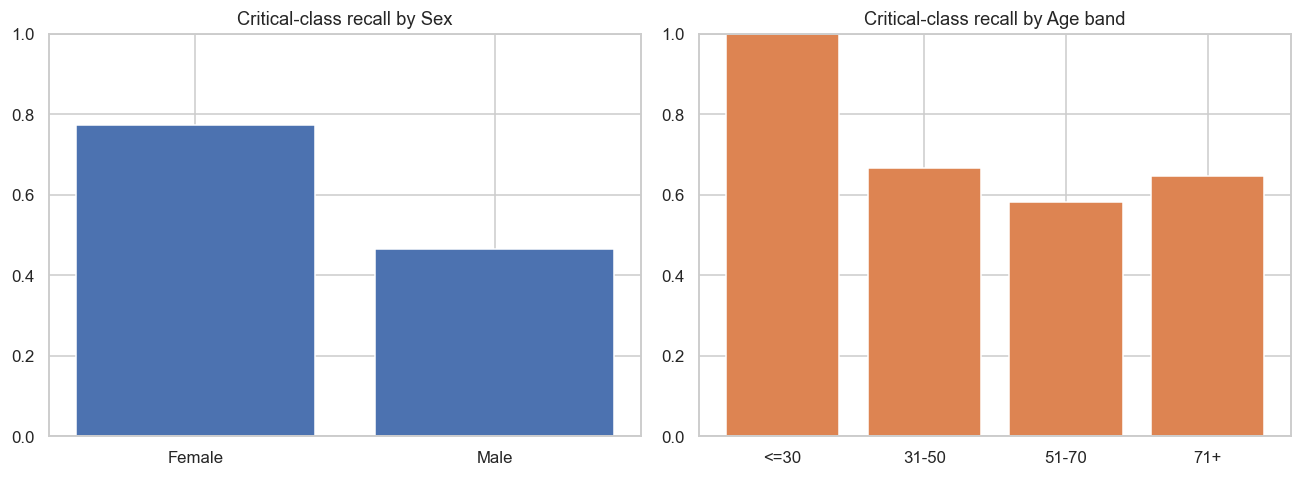

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(sex_report["Sex"].astype(str), sex_report["Critical recall"], color="#4C72B0")
axes[0].set_title("Critical-class recall by Sex")
axes[0].set_ylim(0, 1)
axes[1].bar(age_report["Age_band"].astype(str), age_report["Critical recall"], color="#DD8452")
axes[1].set_title("Critical-class recall by Age band")
axes[1].set_ylim(0, 1)
savefig("subgroup_fairness_critical_recall.png")
plt.show()


**Result — a real fairness gap worth flagging, not dismissing:** Critical-class recall is
**0.77 for Female callers (17/22 correctly flagged) vs. only 0.47 for Male callers (7/15 correctly
flagged)** in the test set — a **30-point gap**. This means, in this test sample, the model misses
more than half of truly critical presentations in male patients while catching over three-quarters
in female patients. By age band, recall ranges from 0.58 (51–70) to 1.00 (<=30, though only n=2 —
too small to trust), with no band showing a fairness-breaking collapse to near-zero. **The
sex-based gap is the more concerning and more statistically grounded of the two** (larger subgroup
sizes: 22 and 15 Critical cases respectively) and should be treated as a real finding requiring
investigation before any deployment — possible causes include differences in how male vs. female
patients or their callers described symptoms in this dataset, or simply small-sample noise (37
total Critical test cases split two ways is still a small base rate to estimate recall from
precisely). Either way, this is exactly the kind of disparity a deployment-readiness review must
resolve — with a larger dataset and a formal statistical test for the gap — before this model could
be trusted operationally.


---
## Saving the final pipeline

We persist the best-performing **primary (caller-obtainable-only)** pipeline with `joblib`, along
with the exact feature column list and class order, so it can be loaded and used to score a new
synthetic call without needing to re-run this notebook. See `scripts/predict_new_call.py` for a
small standalone script that loads this artifact and predicts on a new record.


In [ ]:
import joblib

artifact = {
    "pipeline": explain_pipe,
    "feature_columns": feature_cols_primary,
    "class_order": CLASS_ORDER,
    "model_name": best_model_name,
}
joblib.dump(artifact, "models/triage_pipeline.joblib")
print("Saved models/triage_pipeline.joblib")
print("Model:", best_model_name)
print("Feature columns:", feature_cols_primary)


Saved models/triage_pipeline.joblib
Model: Stacking Ensemble
Feature columns: ['Age', 'NRS_pain', 'Sex', 'Arrival mode', 'Injury', 'Mental', 'Chief_complain_group', 'Caller_relationship']


## Summary

- Built a 3-class (Critical / Urgent / Non-urgent) triage classifier trained **only on
  caller-obtainable phone-call information**, matching the real constraint a dispatcher faces.
- Compared a Logistic Regression baseline, a tuned Random Forest (bagging), a tuned LightGBM
  (boosting), and a leakage-safe heterogeneous stacking ensemble, all evaluated on one untouched
  test set with F1-macro, ROC-AUC, and per-class precision/recall — see §3.5 for the numeric result
  and winner.
- Quantified the "vitals gap" — how much accuracy a phone dispatcher gives up by not having device
  measurements — in §3.6, directly validating the caller-obtainable design constraint from §2.4.
- Explained the best model globally and locally with SHAP (§4.1–4.2), checked subgroup fairness on
  the safety-critical Critical-class recall (§4.4), and laid out concrete deployment limits and a
  human-review policy.
- Saved a reproducible, loadable pipeline artifact for downstream use.

See `README.md` for setup/execution instructions and dataset citation, and
`section5_pitch_script.md` for the 3-minute video script.
